# Tahap : Model & Interpret (OSEMN Framework)
Deskripsi : Analisis Eksploratif (Trend & Distribusi), Analisis Korelasi, Pemodelan Clustering (K-Means), dan Feature Importance (Random Forest)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor

# Pengaturan estetika visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Load Dataset

In [2]:
print("[INFO] Memuat dataset hasil preprocessing...")
df_monthly = pd.read_csv('../data/preprocessed/stunting_cleaned_monthly.csv')
df_yearly = pd.read_csv('../data/preprocessed/stunting_agg_puskesmas_yearly.csv')

# Mengurutkan bulan secara kronologis untuk trend analysis
bulan_order = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 
               'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
df_monthly['bulan'] = pd.Categorical(df_monthly['bulan'], categories=bulan_order, ordered=True)

[INFO] Memuat dataset hasil preprocessing...


## Exploratory Data Analysis (EDA)

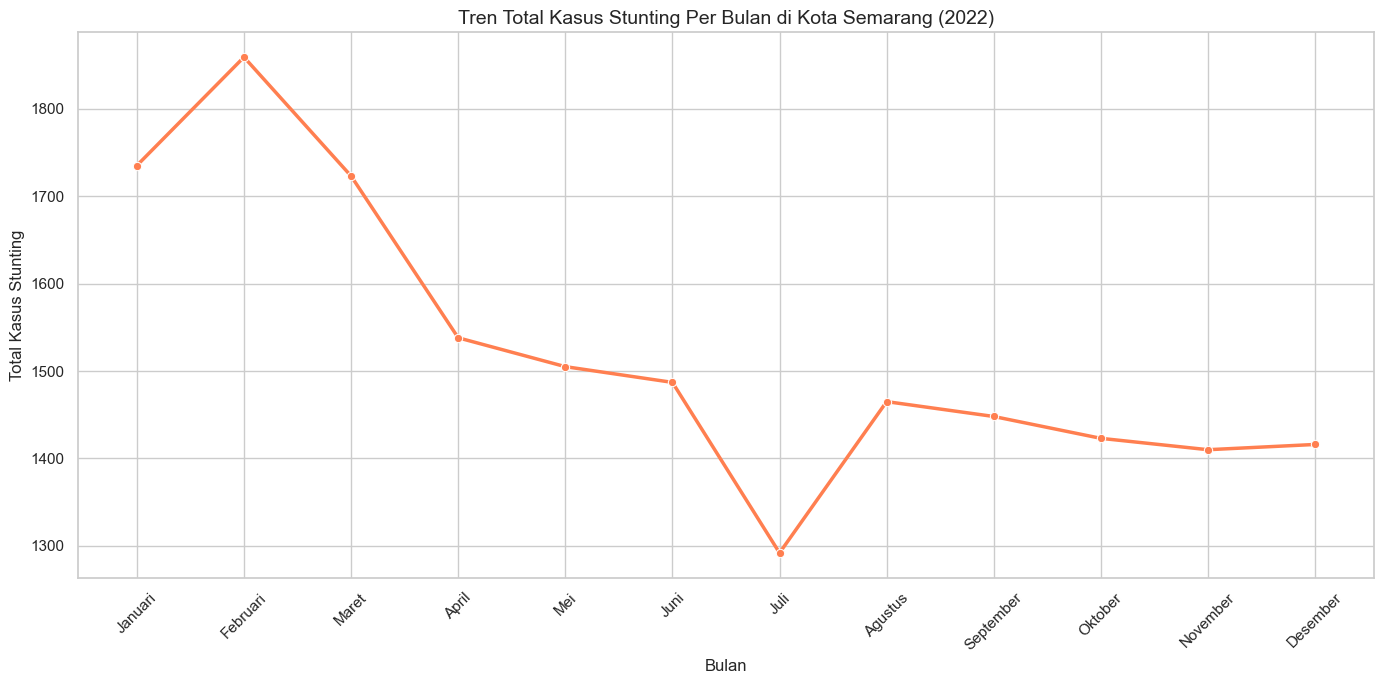

/var/folders/p7/r88t0w8j08s5g74pc9xq7v6r0000gp/T/ipykernel_6898/520719066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kecamatan_stunting, x='total_stunting', y='kecamatan', palette='viridis')


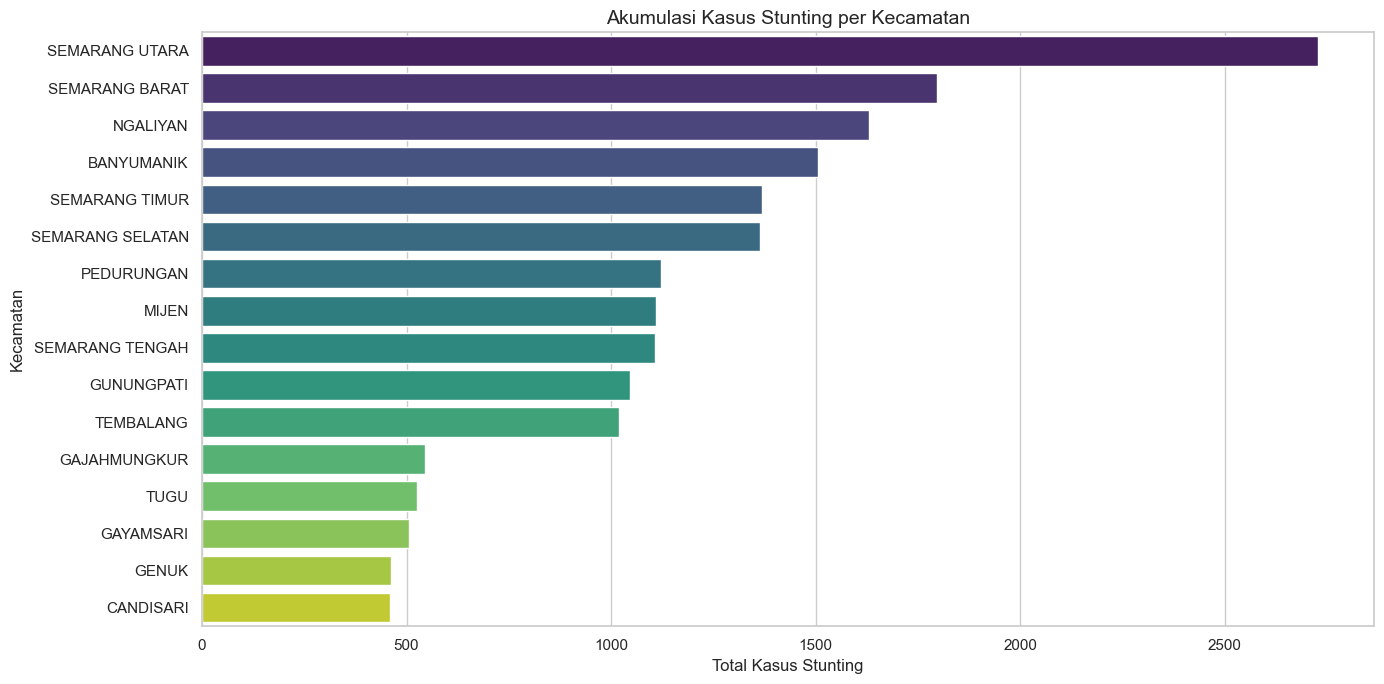

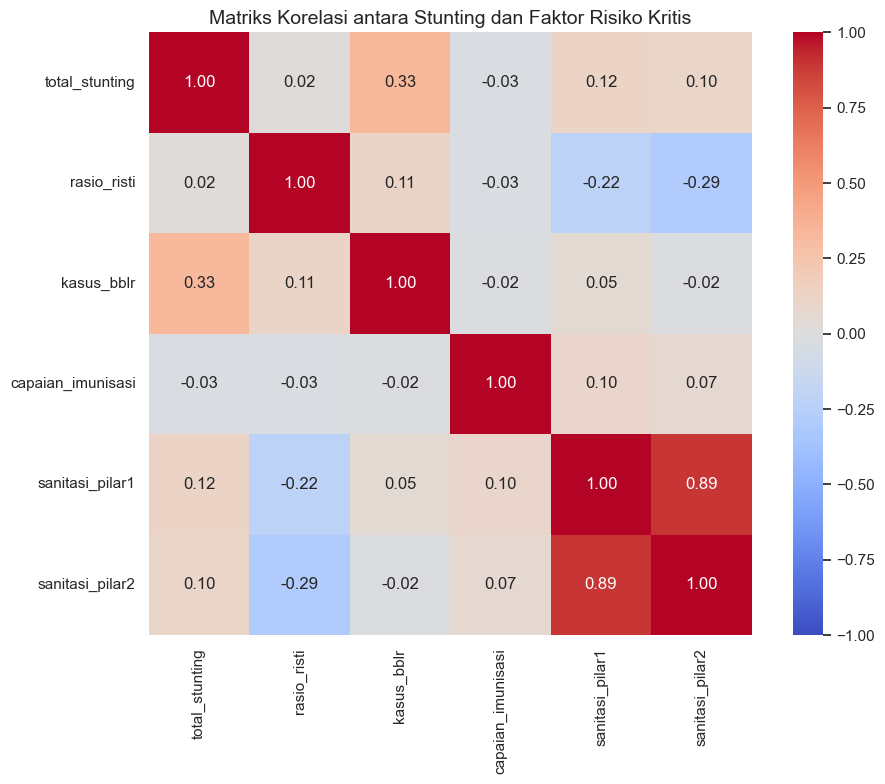

In [3]:
# --- Q1: Analisis Tren Kasus Stunting Bulanan ---
plt.figure(figsize=(14, 7))
trend_data = df_monthly.groupby('bulan')['total_stunting'].sum().reset_index()
sns.lineplot(data=trend_data, x='bulan', y='total_stunting', marker='o', linewidth=2.5, color='coral')
plt.title('Tren Total Kasus Stunting Per Bulan di Kota Semarang (2022)')
plt.xlabel('Bulan')
plt.ylabel('Total Kasus Stunting')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../docs/trend_stunting_bulanan.png', dpi=300)
plt.show()

# --- Q2: Distribusi Kasus Stunting Berdasarkan Kecamatan ---
plt.figure(figsize=(14, 7))
kecamatan_stunting = df_yearly.groupby('kecamatan')['total_stunting'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=kecamatan_stunting, x='total_stunting', y='kecamatan', palette='viridis')
plt.title('Akumulasi Kasus Stunting per Kecamatan')
plt.xlabel('Total Kasus Stunting')
plt.ylabel('Kecamatan')
plt.tight_layout()
plt.show()

# --- Analisis Korelasi Faktor Risiko ---
features_to_correlate = [
    'total_stunting', 'rasio_risti', 'kasus_bblr', 
    'capaian_imunisasi', 'sanitasi_pilar1', 'sanitasi_pilar2'
]
corr_matrix = df_yearly[features_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title('Matriks Korelasi antara Stunting dan Faktor Risiko Kritis')
plt.tight_layout()
plt.show()

## Pemodelan Clustering (K-Means)
Tujuan: Memetakan Puskesmas ke dalam segmen kerentanan (Rendah, Sedang, Tinggi)


[EVALUASI CLUSTERING] Silhouette Score untuk K=3 adalah 0.5099

[PROFIL CLUSTER RATA-RATA]
                total_stunting  rasio_risti  kasus_bblr  capaian_imunisasi
cluster_risiko                                                            
0                   828.000000          NaN         NaN                NaN
1                   405.848485     0.296550   10.545455          72.512626
2                  1360.000000     0.301338   33.000000          73.722222


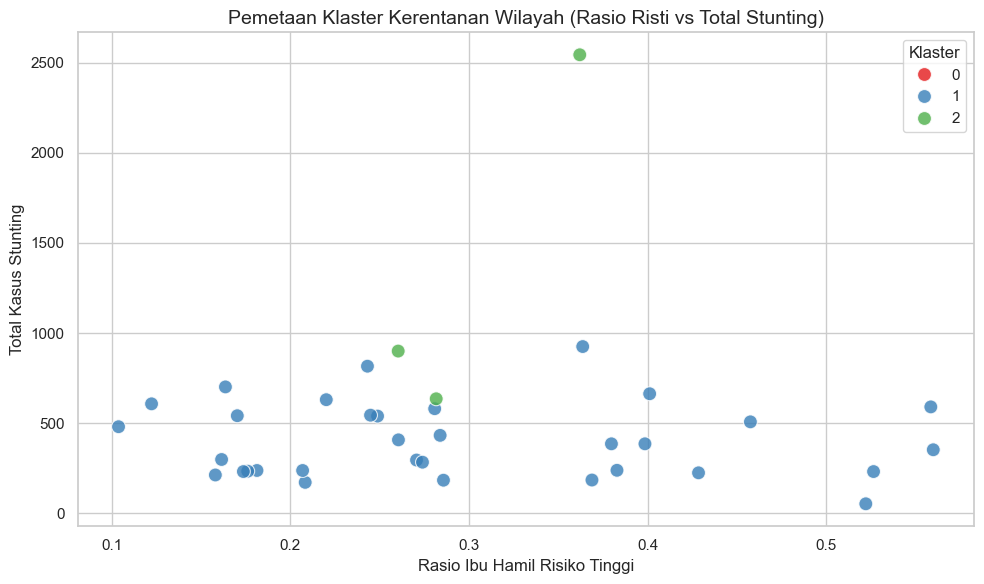

In [7]:
# Memilih fitur yang merepresentasikan kondisi kesehatan dan lingkungan
cluster_features = [
    'total_stunting', 'rasio_risti', 'kasus_bblr', 'capaian_imunisasi'
]
X_cluster = df_yearly[cluster_features].fillna(0) # Penanganan pengaman untuk NaNs

# Standarisasi fitur agar memiliki skala yang sama
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Menentukan nilai K optimal menggunakan Silhouette Score
silhouette_scores = []
K_range = range(2, 7)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# Memilih K dengan skor silhouette tertinggi (biasanya k=3 untuk segmentasi risiko)
optimal_k = 3 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_yearly['cluster_risiko'] = kmeans_final.fit_predict(X_scaled)

print(f"\n[EVALUASI CLUSTERING] Silhouette Score untuk K={optimal_k} adalah {silhouette_score(X_scaled, df_yearly['cluster_risiko']):.4f}")

# Analisis Karakteristik Setiap Cluster
cluster_profiling = df_yearly.groupby('cluster_risiko')[cluster_features].mean()
print("\n[PROFIL CLUSTER RATA-RATA]")
print(cluster_profiling)

# Visualisasi Hasil Clustering (2D Projection menggunakan 2 fitur utama)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_yearly, x='rasio_risti', y='total_stunting', hue='cluster_risiko', 
                palette='Set1', s=100, alpha=0.8)
plt.title('Pemetaan Klaster Kerentanan Wilayah (Rasio Risti vs Total Stunting)')
plt.xlabel('Rasio Ibu Hamil Risiko Tinggi')
plt.ylabel('Total Kasus Stunting')
plt.legend(title='Klaster')
plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)
Tujuan : Menentukan faktor mana yang berkontribusi paling besar terhadap stunting

/var/folders/p7/r88t0w8j08s5g74pc9xq7v6r0000gp/T/ipykernel_6898/231643137.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.head(10), x='Importance', y='Fitur', palette='mako')


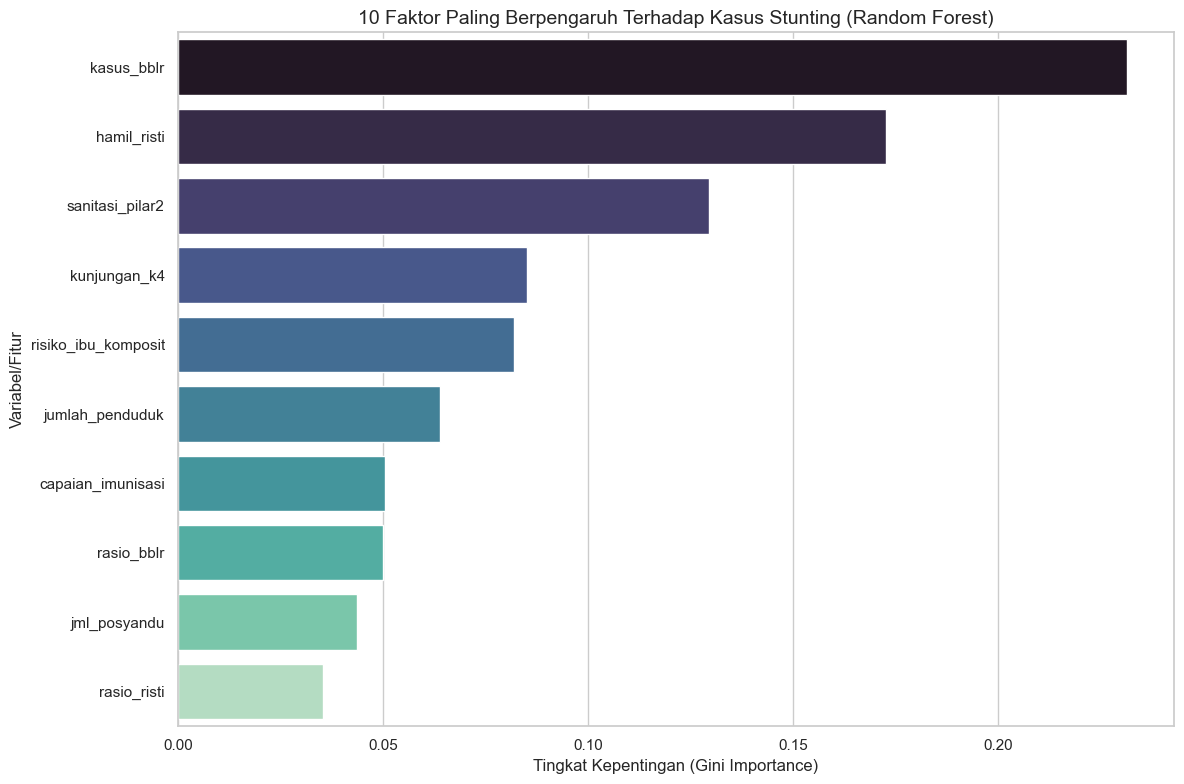


[EVALUASI MODEL REGRESI]
R-squared Score (Training): 0.7856

[INFO] Pipeline pemodelan selesai. Hasil klasterisasi disimpan di 'stunting_clustered_results.csv'


In [8]:
# Variabel prediktor potensial disesuaikan dengan kolom di stunting_agg_puskesmas_yearly
X_rf = df_yearly[[
    'jml_posyandu', 'luas_wilayah_km2', 'jumlah_penduduk', 
    'sanitasi_pilar1', 'sanitasi_pilar2', 'hamil_risti', 
    'rasio_risti', 'risiko_ibu_komposit', 'kunjungan_k4', 
    'kasus_bblr', 'rasio_bblr', 'capaian_imunisasi'
]].fillna(0)

y_rf = df_yearly['total_stunting'].fillna(0)

# Inisialisasi dan pelatihan model
# Menggunakan hiperparameter default yang optimal untuk dataset kecil/menengah
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
rf_model.fit(X_rf, y_rf)

# Ekstraksi dan pengurutan fitur berdasarkan tingkat kepentingan
feature_importances = pd.DataFrame({
    'Fitur': X_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualisasi Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances.head(10), x='Importance', y='Fitur', palette='mako')
plt.title('10 Faktor Paling Berpengaruh Terhadap Kasus Stunting (Random Forest)')
plt.xlabel('Tingkat Kepentingan (Gini Importance)')
plt.ylabel('Variabel/Fitur')
plt.tight_layout()
plt.savefig('../docs/feature_importance_rf.png', dpi=300)
plt.show()

print("\n[EVALUASI MODEL REGRESI]")
print(f"R-squared Score (Training): {rf_model.score(X_rf, y_rf):.4f}")

# Menyimpan dataset yang telah memiliki label klaster untuk diolah di Dashboard
df_yearly.to_csv('../data/integrated/stunting_clustered_results.csv', index=False)
print("\n[INFO] Pipeline pemodelan selesai. Hasil klasterisasi disimpan di 'stunting_clustered_results.csv'")